# MLP Attack Accuracy Sweep
Train MLP attacks on PUF models and sweep environmental conditions.

## Reproduce this notebook
1. Install dependencies from `pypuf/requirements.txt`.
2. Open this file in Jupyter.
3. Run each cell sequentially to generate the models and plots.

## Example output
![Representative output](../USE_CASE/graphs_metrics/ArbiterPUF_metrics_vs_temperature.png)


In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_environmental_heatmap(
    accuracies,
    temp_range,
    vdd_range,
    puf_name,
    attack_name,
    save_full_grid=True,
    save_summary=True
):
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(accuracies, cmap="viridis", interpolation='nearest', origin='lower')
    
    cbar = ax.figure.colorbar(im, ax=ax)
    cbar.ax.set_ylabel("Model Accuracy", rotation=-90, va="bottom")

    ax.set_xticks(np.arange(len(vdd_range)))
    ax.set_yticks(np.arange(len(temp_range)))
    ax.set_xticklabels(vdd_range)
    ax.set_yticklabels(temp_range)
    ax.set_xlabel("Vdd (V)")
    ax.set_ylabel("Temperature (°C)")

    ax.set_title(f"{attack_name} Accuracy vs. Environment\nTarget: {puf_name}")
    plt.tight_layout()
    plt.show()

    # ==============================
    # 🔹 FULL GRID CSV (per PUF)
    # ==============================
    if save_full_grid:
        rows = []
        for i, T in enumerate(temp_range):
            for j, V in enumerate(vdd_range):
                rows.append({
                    "PUF_Type": puf_name,
                    "Attack_Type": attack_name,
                    "Temperature": T,
                    "Voltage": V,
                    "Accuracy": float(accuracies[i, j])
                })

        df_full = pd.DataFrame(rows)

        full_csv_name = f"{puf_name}_master_accuracy.csv"

        if os.path.exists(full_csv_name):
            df_full.to_csv(full_csv_name, mode='a', header=False, index=False)
        else:
            df_full.to_csv(full_csv_name, mode='w', header=True, index=False)

        print(f"Saved full grid accuracy to {full_csv_name}")

    # ==============================
    # 🔹 SUMMARY STATS (ALL PUFs)
    # ==============================
    if save_summary:
        flat_acc = accuracies.flatten()

        mean_acc = np.mean(flat_acc)
        std_acc = np.std(flat_acc)
        min_acc = np.min(flat_acc)
        max_acc = np.max(flat_acc)

        summary_row = {
            "PUF_Type": puf_name,
            "Attack_Type": attack_name,
            "Mean_Accuracy": mean_acc,
            "Std_Accuracy": std_acc,
            "Min_Accuracy": min_acc,
            "Max_Accuracy": max_acc,
            "Num_Grid_Points": len(flat_acc)
        }

        df_summary = pd.DataFrame([summary_row])

        summary_csv_name = "ALL_PUF_attack_summary.csv"

        if os.path.exists(summary_csv_name):
            df_summary.to_csv(summary_csv_name, mode='a', header=False, index=False)
        else:
            df_summary.to_csv(summary_csv_name, mode='w', header=True, index=False)

        print(f"Saved summary stats to {summary_csv_name}")
        print(f"Mean: {mean_acc:.4f}, Std: {std_acc:.4f}")


Epoch 1/50
50/50 [==============================] - 2s 11ms/step - loss: 0.6274 - accuracy: 0.6457 - val_loss: 0.5198 - val_accuracy: 0.7640
Epoch 2/50
50/50 [==============================] - 0s 4ms/step - loss: 0.4867 - accuracy: 0.7997 - val_loss: 0.4244 - val_accuracy: 0.8400
Epoch 3/50
50/50 [==============================] - 0s 4ms/step - loss: 0.4084 - accuracy: 0.8606 - val_loss: 0.3672 - val_accuracy: 0.8940
Epoch 4/50
50/50 [==============================] - 0s 5ms/step - loss: 0.3577 - accuracy: 0.8920 - val_loss: 0.3279 - val_accuracy: 0.9120
Epoch 5/50
50/50 [==============================] - 0s 4ms/step - loss: 0.3214 - accuracy: 0.9119 - val_loss: 0.2989 - val_accuracy: 0.9240
Epoch 6/50
50/50 [==============================] - 0s 6ms/step - loss: 0.2939 - accuracy: 0.9247 - val_loss: 0.2763 - val_accuracy: 0.9260
Epoch 7/50
50/50 [==============================] - 0s 4ms/step - loss: 0.2720 - accuracy: 0.9345 - val_loss: 0.2576 - val_accuracy: 0.9420
Epoch 8/50
50/50 [=

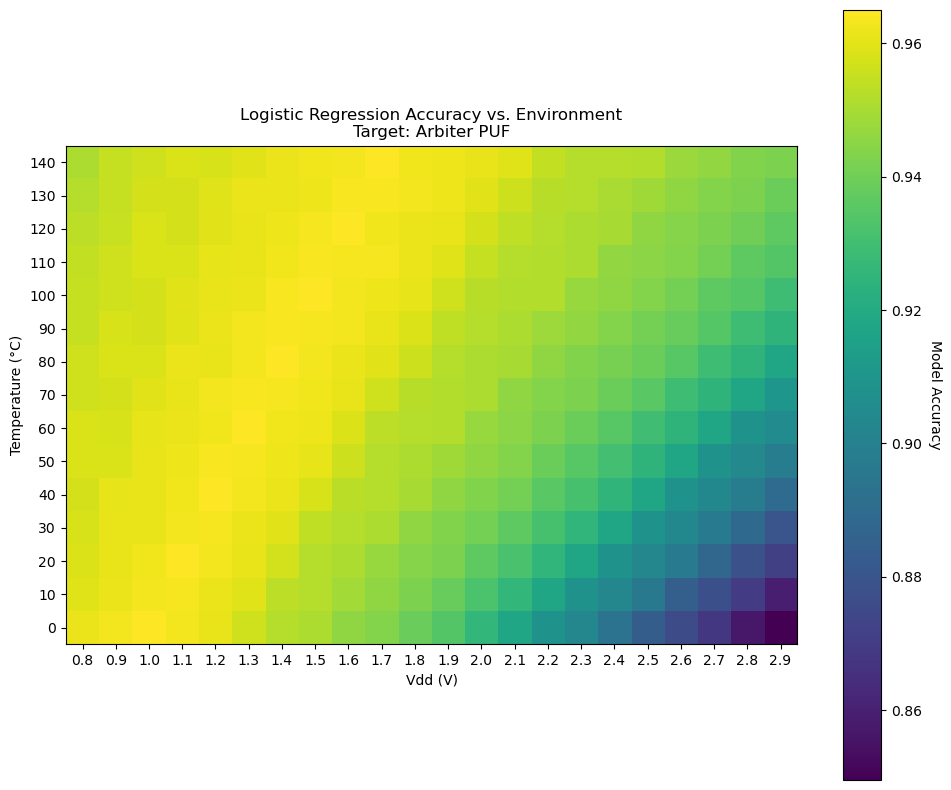

Saved full grid accuracy to Arbiter PUF_master_accuracy.csv
Saved summary stats to ALL_PUF_attack_summary.csv
Mean: 0.9446, Std: 0.0225


In [5]:
from pypuf.simulation import ArbiterPUF
from pypuf.io import ChallengeResponseSet
from pypuf.attack import LRAttack2021
from pypuf.metrics import similarity

# 1. Setup
n_bits, puf_seed = 64, 123
nom_temp, nom_vdd = 25.0, 1.2
n_train, n_test = 50000, 2000
temp_range = np.arange(0, 150, 10)
vdd_range = np.round(np.arange(0.8, 3.00, 0.1), 2)

# 2. Train at Nominal (Golden Point)
p_nom = ArbiterPUF(n=n_bits, seed=puf_seed, noisiness=0.05, temperature=nom_temp, vdd=nom_vdd)
train_crps = ChallengeResponseSet.from_simulation(p_nom, N=n_train, seed= puf_seed)
# LR: (crps, seed, k, bs, lr, epochs) [cite: 39, 46]
model = LRAttack2021(train_crps, 42, 1, 1000, 1e-3, 50).fit() #[cite: 58]
model.temperature, model.vdd = nom_temp, nom_vdd


# 3. Environmental Sweep
acc_grid = np.zeros((len(temp_range), len(vdd_range)))
for i, t in enumerate(temp_range):
    for j, v in enumerate(vdd_range):
        p_eval = ArbiterPUF(n=n_bits, seed=puf_seed, temperature=t, vdd=v)
        acc_grid[i, j] = similarity(p_eval, model, seed=42, N=n_test)[0] #[cite: 358]

plot_environmental_heatmap(acc_grid, temp_range, vdd_range, "Arbiter PUF", "Logistic Regression")

In [6]:
from pypuf.simulation import ArbiterPUF
from pypuf.io import ChallengeResponseSet
from pypuf.attack import MLPAttack2021
from pypuf.metrics import similarity

# 1. Setup (Inherited from your previous configuration)
n_bits, puf_seed = 64, 123
nom_temp, nom_vdd = 25.0, 1.2
n_train, n_test = 50000, 2000
temp_range = np.arange(0, 150, 10)
vdd_range = np.round(np.arange(0.8, 3.00, 0.1), 2)

# 2. Train at Nominal (Golden Point)
p_nom = ArbiterPUF(n=n_bits, seed=puf_seed, noisiness=0.05, temperature=nom_temp, vdd=nom_vdd)
train_crps = ChallengeResponseSet.from_simulation(p_nom, N=n_train, seed=puf_seed)

# MLP Attack Configuration:
# Arguments: (crps, seed, net, epochs, lr, bs, early_stop)
# net=[n_bits, n_bits] defines two hidden layers matching the challenge length
model = MLPAttack2021(
    train_crps, 
    seed=42, 
    net=[n_bits, n_bits], 
    epochs=50, 
    lr=1e-3, 
    bs=128, 
    early_stop=0.01
).fit()

# Assign nominal conditions for physics-aware evaluation
model.temperature, model.vdd = nom_temp, nom_vdd

# 3. Environmental Sweep
acc_grid = np.zeros((len(temp_range), len(vdd_range)))
for i, t in enumerate(temp_range):
    for j, v in enumerate(vdd_range):
        # Create target instance with shifted environmental parameters
        p_eval = ArbiterPUF(n=n_bits, seed=puf_seed, temperature=t, vdd=v)
        
        # similarity() compares the fixed MLP model against the shifted device
        acc_grid[i, j] = similarity(p_eval, model, seed=42, N=n_test)[0]

# 4. Visualization
plot_environmental_heatmap(acc_grid, temp_range, vdd_range, "Arbiter PUF", "MLP Attack")

Epoch 1/50
387/387 [==============================] - 3s 4ms/step - loss: 0.1091 - accuracy: 0.9567 - val_loss: 0.0552 - val_accuracy: 0.9760
Epoch 2/50
387/387 [==============================] - 1s 3ms/step - loss: 0.0509 - accuracy: 0.9778 - val_loss: 0.0582 - val_accuracy: 0.9780
Epoch 3/50
387/387 [==============================] - 1s 2ms/step - loss: 0.0481 - accuracy: 0.9782 - val_loss: 0.0669 - val_accuracy: 0.9740
Epoch 4/50
387/387 [==============================] - 1s 3ms/step - loss: 0.0448 - accuracy: 0.9805 - val_loss: 0.0441 - val_accuracy: 0.9820
Epoch 5/50
387/387 [==============================] - 1s 3ms/step - loss: 0.0439 - accuracy: 0.9807 - val_loss: 0.0421 - val_accuracy: 0.9800
Epoch 6/50
387/387 [==============================] - 1s 3ms/step - loss: 0.0423 - accuracy: 0.9823 - val_loss: 0.0502 - val_accuracy: 0.9720
Epoch 7/50
387/387 [==============================] - 1s 3ms/step - loss: 0.0416 - accuracy: 0.9818 - val_loss: 0.0528 - val_accuracy: 0.9660
Epoch 

KeyboardInterrupt: 

Epoch 1/50
774/774 [==============================] - 3s 2ms/step - loss: 0.6999 - accuracy: 0.4988 - val_loss: 0.6954 - val_accuracy: 0.5100
Epoch 2/50
774/774 [==============================] - 2s 2ms/step - loss: 0.6956 - accuracy: 0.5066 - val_loss: 0.6937 - val_accuracy: 0.5210
Epoch 3/50
774/774 [==============================] - 2s 2ms/step - loss: 0.6943 - accuracy: 0.5095 - val_loss: 0.6961 - val_accuracy: 0.5100
Epoch 4/50
774/774 [==============================] - 2s 2ms/step - loss: 0.6930 - accuracy: 0.5191 - val_loss: 0.6912 - val_accuracy: 0.5360
Epoch 5/50
774/774 [==============================] - 2s 2ms/step - loss: 0.6914 - accuracy: 0.5248 - val_loss: 0.6931 - val_accuracy: 0.5360
Epoch 6/50
774/774 [==============================] - 2s 2ms/step - loss: 0.6894 - accuracy: 0.5365 - val_loss: 0.6984 - val_accuracy: 0.5140
Epoch 7/50
774/774 [==============================] - 2s 2ms/step - loss: 0.6854 - accuracy: 0.5494 - val_loss: 0.6849 - val_accuracy: 0.5390
Epoch 

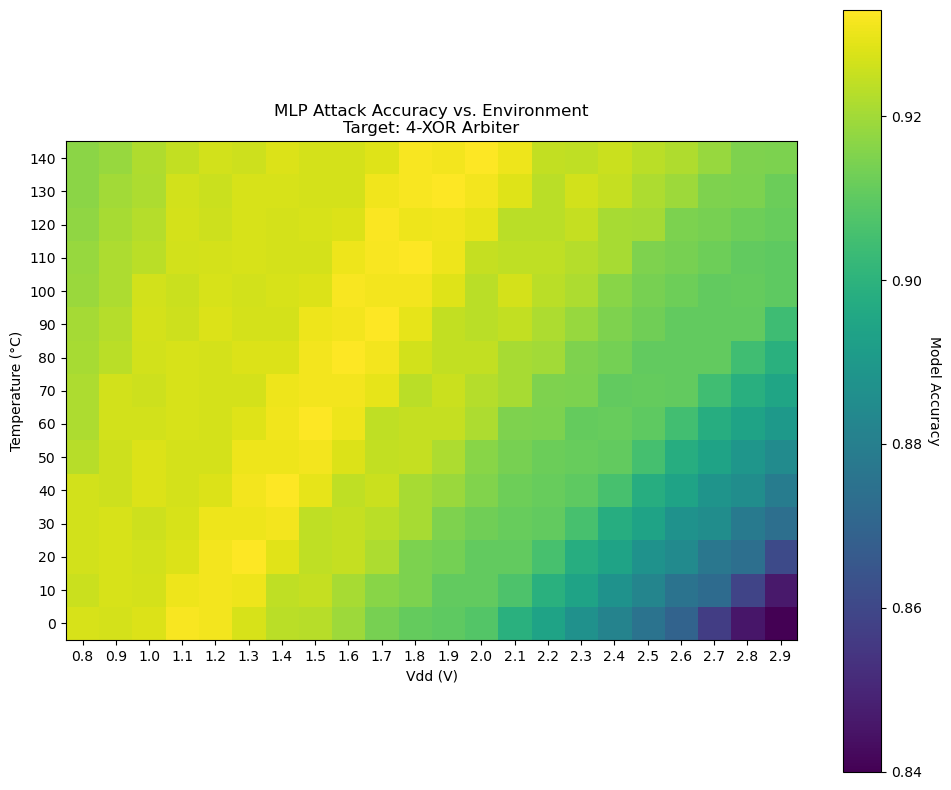

Saved full grid accuracy to 4-XOR Arbiter_master_accuracy.csv
Saved summary stats to ALL_PUF_attack_summary.csv
Mean: 0.9171, Std: 0.0161


In [ ]:
from pypuf.simulation import XORArbiterPUF
from pypuf.attack import MLPAttack2021

k = 4
p_nom = XORArbiterPUF(n=n_bits, k=k, seed=puf_seed, noisiness=0.05, temperature=nom_temp, vdd=nom_vdd) #[cite: 13, 161]
train_crps = ChallengeResponseSet.from_simulation(p_nom, N=100000, seed=puf_seed) # Increased data for XOR

# MLP: (crps, seed, net, epochs, lr, bs, early_stop) [cite: 204, 209]
model = MLPAttack2021(train_crps, 42, [n_bits, n_bits], 50, 1e-3, 128, 0.01).fit() #[cite: 171]
model.temperature, model.vdd = nom_temp, nom_vdd

acc_grid = np.zeros((len(temp_range), len(vdd_range)))
for i, t in enumerate(temp_range):
    for j, v in enumerate(vdd_range):
        p_eval = XORArbiterPUF(n=n_bits, k=k, seed=puf_seed, temperature=t, vdd=v)
        acc_grid[i, j] = similarity(p_eval, model, seed=42, N=n_test)[0] #3[cite: 182]

plot_environmental_heatmap(acc_grid, temp_range, vdd_range, f"{k}-XOR Arbiter", "MLP Attack")

Epoch 1/50
387/387 [==============================] - 2s 3ms/step - loss: 0.3655 - accuracy: 0.8269 - val_loss: 0.3512 - val_accuracy: 0.8540
Epoch 2/50
387/387 [==============================] - 1s 2ms/step - loss: 0.3425 - accuracy: 0.8398 - val_loss: 0.3427 - val_accuracy: 0.8420
Epoch 3/50
387/387 [==============================] - 1s 3ms/step - loss: 0.3348 - accuracy: 0.8428 - val_loss: 0.3426 - val_accuracy: 0.8500
Epoch 4/50
387/387 [==============================] - 1s 2ms/step - loss: 0.3005 - accuracy: 0.8620 - val_loss: 0.2811 - val_accuracy: 0.8760
Epoch 5/50
387/387 [==============================] - 1s 3ms/step - loss: 0.2618 - accuracy: 0.8823 - val_loss: 0.2559 - val_accuracy: 0.8780
Epoch 6/50
387/387 [==============================] - 1s 2ms/step - loss: 0.2361 - accuracy: 0.8952 - val_loss: 0.2330 - val_accuracy: 0.8960
Epoch 7/50
387/387 [==============================] - 1s 2ms/step - loss: 0.2136 - accuracy: 0.9063 - val_loss: 0.2154 - val_accuracy: 0.9100
Epoch 

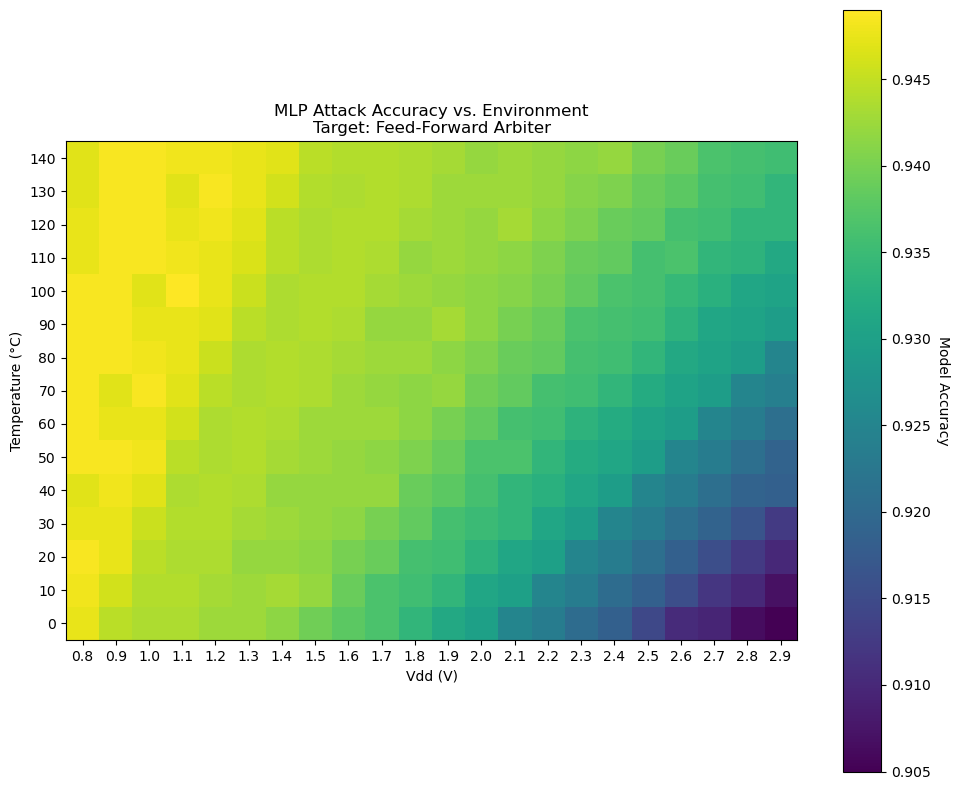

Saved full grid accuracy to Feed-Forward Arbiter_master_accuracy.csv
Saved summary stats to ALL_PUF_attack_summary.csv
Mean: 0.9380, Std: 0.0094


In [ ]:
from pypuf.simulation import FeedForwardArbiterPUF

# Define FF bit indices: [(trigger_index, target_index), ...]
p_nom = FeedForwardArbiterPUF(n=n_bits, ff=[(10, 20), (30, 40)], seed=puf_seed, temperature=nom_temp, vdd=nom_vdd)
train_crps = ChallengeResponseSet.from_simulation(p_nom, N=n_train, seed=puf_seed)

model = MLPAttack2021(train_crps, 42, [n_bits, n_bits], 50, 1e-3, 128, 0.01).fit()
model.temperature, model.vdd = nom_temp, nom_vdd

acc_grid = np.zeros((len(temp_range), len(vdd_range)))
for i, t in enumerate(temp_range):
    for j, v in enumerate(vdd_range):
        p_eval = FeedForwardArbiterPUF(n=n_bits, ff=[(10, 20), (30, 40)], seed=puf_seed, temperature=t, vdd=v)
        acc_grid[i, j] = similarity(p_eval, model, seed=42, N=n_test)[0]

plot_environmental_heatmap(acc_grid, temp_range, vdd_range, "Feed-Forward Arbiter", "MLP Attack")

Epoch 1/50
387/387 [==============================] - 2s 3ms/step - loss: 0.7007 - accuracy: 0.5033 - val_loss: 0.6953 - val_accuracy: 0.4980
Epoch 2/50
387/387 [==============================] - 1s 3ms/step - loss: 0.6955 - accuracy: 0.5105 - val_loss: 0.6977 - val_accuracy: 0.5080
Epoch 3/50
387/387 [==============================] - 1s 2ms/step - loss: 0.6935 - accuracy: 0.5191 - val_loss: 0.7073 - val_accuracy: 0.4620
Epoch 4/50
387/387 [==============================] - 1s 2ms/step - loss: 0.6918 - accuracy: 0.5265 - val_loss: 0.6991 - val_accuracy: 0.4880
Epoch 5/50
387/387 [==============================] - 1s 2ms/step - loss: 0.6889 - accuracy: 0.5384 - val_loss: 0.7007 - val_accuracy: 0.5100
Epoch 6/50
387/387 [==============================] - 1s 2ms/step - loss: 0.6859 - accuracy: 0.5464 - val_loss: 0.7025 - val_accuracy: 0.4920
Epoch 7/50
387/387 [==============================] - 1s 3ms/step - loss: 0.6832 - accuracy: 0.5573 - val_loss: 0.7069 - val_accuracy: 0.5040
Epoch 

Stopping early as overfitting of more than 15% in accuracy was detected.


63/63 [==============================] - 0s 2ms/step


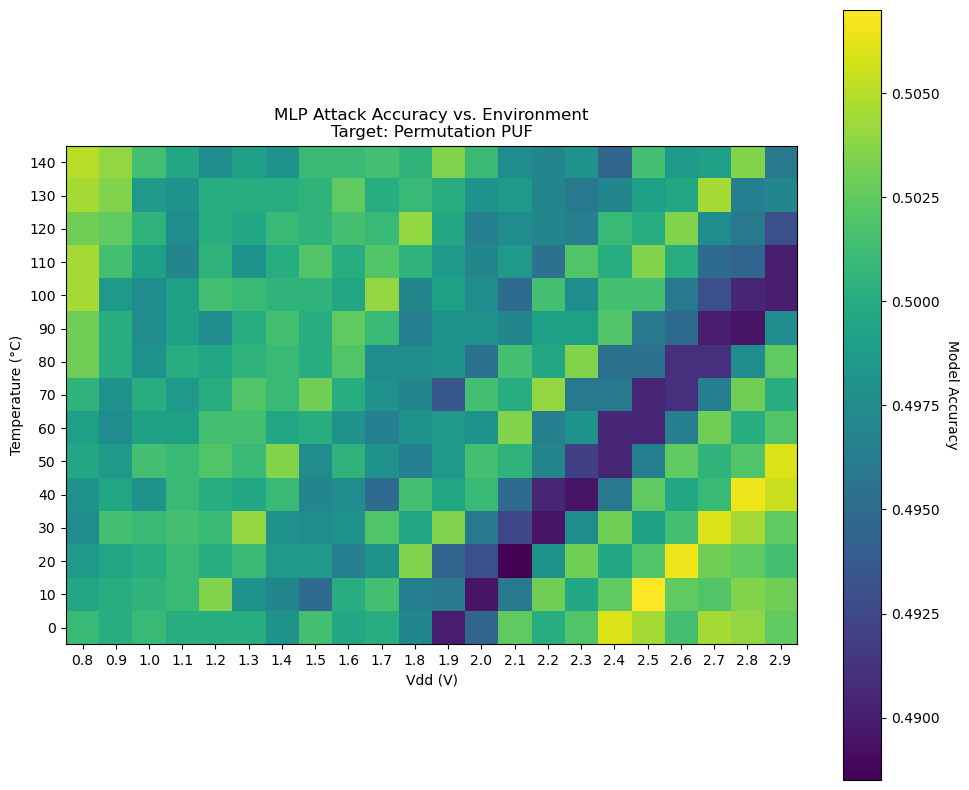

Saved full grid accuracy to Permutation PUF_master_accuracy.csv
Saved summary stats to ALL_PUF_attack_summary.csv
Mean: 0.4992, Std: 0.0034


In [11]:
from pypuf.simulation import PermutationPUF
from pypuf.io import ChallengeResponseSet
from pypuf.attack import MLPAttack2021
from pypuf.metrics import similarity

# 1. Setup Data Generation at Nominal Conditions
# Permutation PUFs utilize k-length blocks to shuffle bit mappings
p_nom = PermutationPUF(n=n_bits, seed=puf_seed, temperature=nom_temp, vdd=nom_vdd, k=8)
train_crps = ChallengeResponseSet.from_simulation(p_nom, N=n_train, seed=puf_seed)

# 2. Run MLP Attack
# net=[n_bits, n_bits] defines the hidden layers for the neural network
# bs=128 is the standard batch size for gradient-based pypuf attacks
model = MLPAttack2021(
    train_crps, 
    seed=42, 
    net=[n_bits, n_bits], 
    epochs=50, 
    lr=1e-3, 
    bs=128, 
    early_stop=0.01
).fit()

# Ensure the model knows it was trained at nominal conditions for physics evaluation
model.temperature, model.vdd = nom_temp, nom_vdd

# 3. Environmental Sweep Evaluation
acc_grid = np.zeros((len(temp_range), len(vdd_range)))
for i, t in enumerate(temp_range):
    for j, v in enumerate(vdd_range):
        # Create target instance with shifted environmental parameters
        p_eval = PermutationPUF(n=n_bits, seed=puf_seed, temperature=t, vdd=v, k=8)
        
        # similarity() compares the fixed MLP model against the shifted device
        # seed=4 internally generates random inputs for verification [cite: 30]
        acc_grid[i, j] = similarity(p_eval, model, seed=42, N=n_test)[0]

# 4. Visualize Results
plot_environmental_heatmap(acc_grid, temp_range, vdd_range, "Permutation PUF", "MLP Attack")

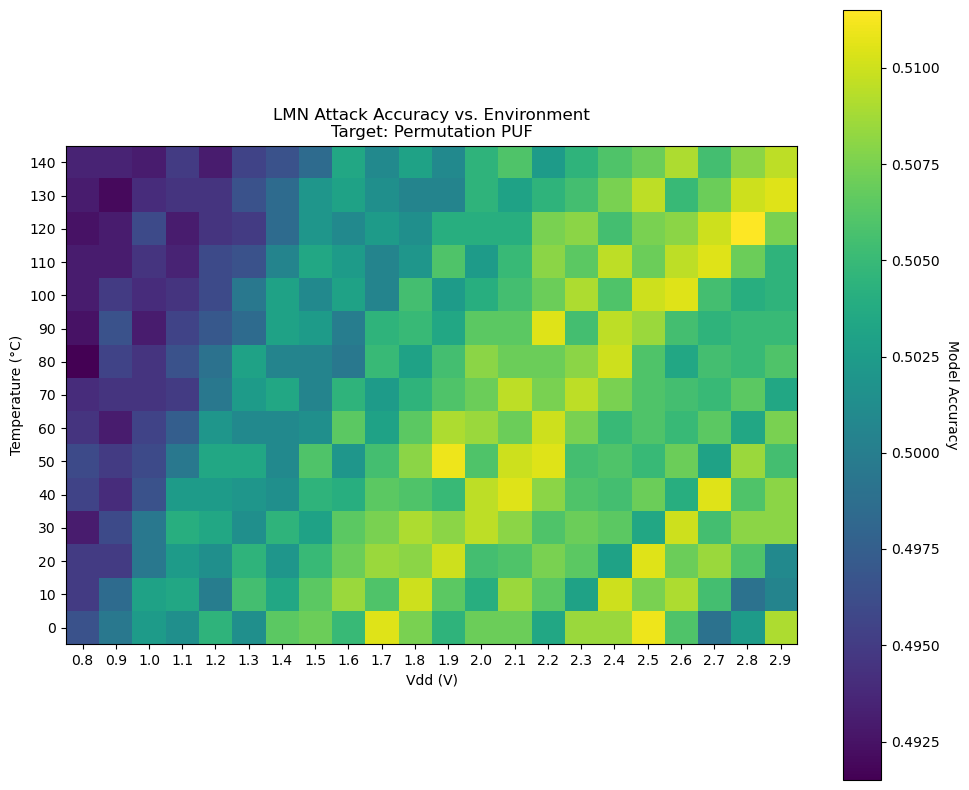

Saved full grid accuracy to Permutation PUF_master_accuracy.csv
Saved summary stats to ALL_PUF_attack_summary.csv
Mean: 0.5033, Std: 0.0050


In [ ]:
from pypuf.simulation import PermutationPUF
from pypuf.io import ChallengeResponseSet
from pypuf.attack import LMNAttack  # 
from pypuf.metrics import similarity

# 1. Setup Data Generation at Nominal Conditions
p_nom = PermutationPUF(n=n_bits, seed=puf_seed, temperature=nom_temp, vdd=nom_vdd, k=8)
train_crps = ChallengeResponseSet.from_simulation(p_nom, N=n_train, seed=puf_seed)

# 2. Run LMN Attack
# Degree 1 approximations are computationally linear and highly effective [cite: 17, 18, 32]
model = LMNAttack(train_crps, deg=1).fit()  # [cite: 22, 23, 32]

# Ensure the model knows it was trained at nominal conditions for physics evaluation
model.temperature, model.vdd = nom_temp, nom_vdd

# 3. Environmental Sweep Evaluation
acc_grid = np.zeros((len(temp_range), len(vdd_range)))
for i, t in enumerate(temp_range):
    for j, v in enumerate(vdd_range):
        # Create target instance with shifted environmental parameters
        p_eval = PermutationPUF(n=n_bits, seed=puf_seed, temperature=t, vdd=v, k=8)
        
        # similarity() compares the fixed LMN model against the shifted device 
        acc_grid[i, j] = similarity(p_eval, model, seed=42, N=n_test)[0]

# 4. Visualize Results
plot_environmental_heatmap(acc_grid, temp_range, vdd_range, "Permutation PUF", "LMN Attack")

Epoch 1/50
1161/1161 [==============================] - 6s 3ms/step - loss: 0.6887 - accuracy: 0.5556 - val_loss: 0.6898 - val_accuracy: 0.5370
Epoch 2/50
1161/1161 [==============================] - 4s 3ms/step - loss: 0.6846 - accuracy: 0.5627 - val_loss: 0.6877 - val_accuracy: 0.5543
Epoch 3/50
1161/1161 [==============================] - 4s 3ms/step - loss: 0.6816 - accuracy: 0.5687 - val_loss: 0.6797 - val_accuracy: 0.5823
Epoch 4/50
1161/1161 [==============================] - 4s 3ms/step - loss: 0.6350 - accuracy: 0.6410 - val_loss: 0.5902 - val_accuracy: 0.6783
Epoch 5/50
1161/1161 [==============================] - 3s 3ms/step - loss: 0.5483 - accuracy: 0.7266 - val_loss: 0.5367 - val_accuracy: 0.7383
Epoch 6/50
1161/1161 [==============================] - 3s 3ms/step - loss: 0.5117 - accuracy: 0.7457 - val_loss: 0.5175 - val_accuracy: 0.7320
Epoch 7/50
1161/1161 [==============================] - 3s 3ms/step - loss: 0.4963 - accuracy: 0.7493 - val_loss: 0.5027 - val_accuracy:

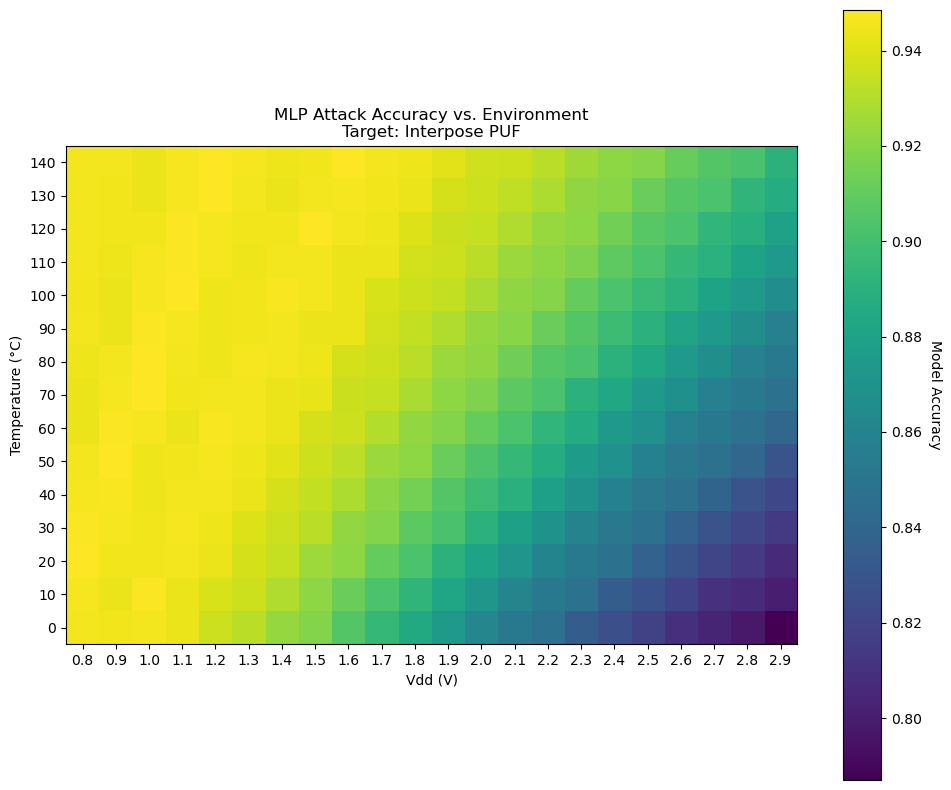

Saved full grid accuracy to Interpose PUF_master_accuracy.csv
Saved summary stats to ALL_PUF_attack_summary.csv
Mean: 0.9098, Std: 0.0403


In [7]:
from pypuf.simulation import InterposePUF

# k_up and k_down represent the number of chains in the top and bottom segments
p_nom = InterposePUF(n=n_bits, k_up=2, k_down=2, seed=puf_seed, temperature=nom_temp, vdd=nom_vdd)
train_crps = ChallengeResponseSet.from_simulation(p_nom, N=300000, seed=puf_seed) # Requires large N

model = MLPAttack2021(train_crps, 42, [n_bits, n_bits, n_bits], 50, 1e-4, 256, 0.01).fit()
model.temperature, model.vdd = nom_temp, nom_vdd

acc_grid = np.zeros((len(temp_range), len(vdd_range)))
for i, t in enumerate(temp_range):
    for j, v in enumerate(vdd_range):
        p_eval = InterposePUF(n=n_bits, k_up=2, k_down=2, seed=puf_seed, temperature=t, vdd=v)
        acc_grid[i, j] = similarity(p_eval, model, seed=42, N=n_test)[0]

plot_environmental_heatmap(acc_grid, temp_range, vdd_range, "Interpose PUF", "MLP Attack")

Epoch 1/50
387/387 [==============================] - 2s 3ms/step - loss: 0.7014 - accuracy: 0.4990 - val_loss: 0.6938 - val_accuracy: 0.5020
Epoch 2/50
387/387 [==============================] - 1s 3ms/step - loss: 0.6958 - accuracy: 0.5092 - val_loss: 0.6965 - val_accuracy: 0.5100
Epoch 3/50
387/387 [==============================] - 1s 3ms/step - loss: 0.6937 - accuracy: 0.5163 - val_loss: 0.7016 - val_accuracy: 0.4720
Epoch 4/50
387/387 [==============================] - 1s 3ms/step - loss: 0.6915 - accuracy: 0.5271 - val_loss: 0.6969 - val_accuracy: 0.5100
Epoch 5/50
387/387 [==============================] - 1s 2ms/step - loss: 0.6886 - accuracy: 0.5382 - val_loss: 0.6953 - val_accuracy: 0.5000
Epoch 6/50
387/387 [==============================] - 1s 3ms/step - loss: 0.6859 - accuracy: 0.5463 - val_loss: 0.6914 - val_accuracy: 0.5560
Epoch 7/50
387/387 [==============================] - 1s 3ms/step - loss: 0.6834 - accuracy: 0.5555 - val_loss: 0.7035 - val_accuracy: 0.4800
Epoch 

Stopping early as overfitting of more than 15% in accuracy was detected.


63/63 [==============================] - 0s 2ms/step


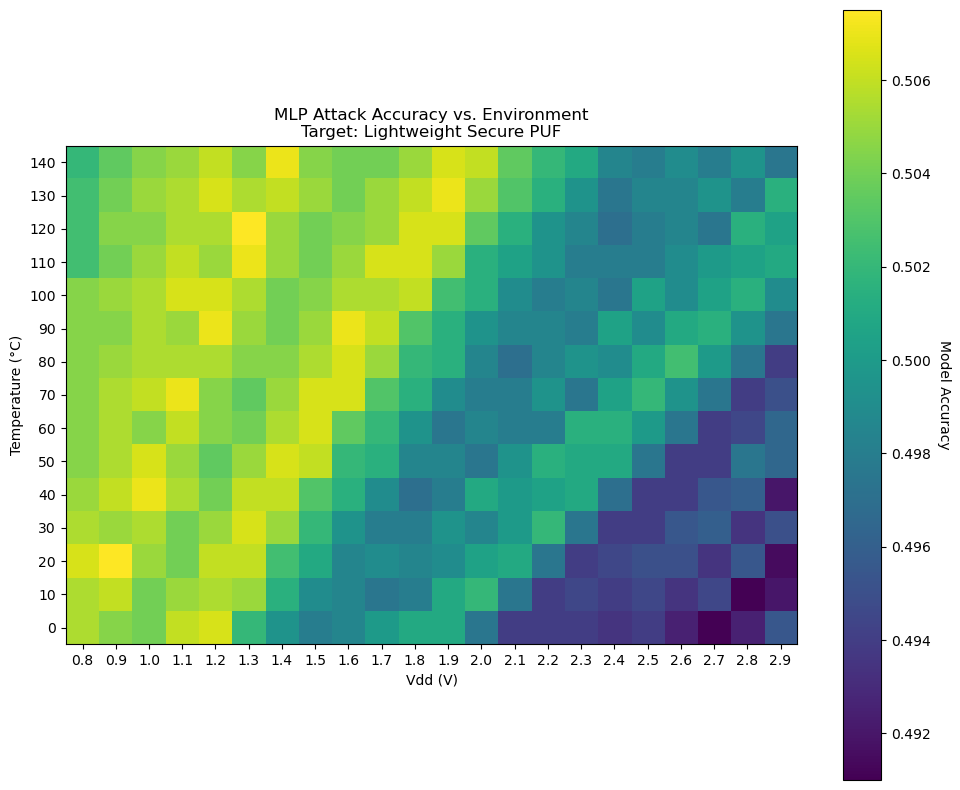

Saved full grid accuracy to Lightweight Secure PUF_master_accuracy.csv
Saved summary stats to ALL_PUF_attack_summary.csv
Mean: 0.5012, Std: 0.0041


In [ ]:
from pypuf.simulation import LightweightSecurePUF

# LightweightSecurePUF with k=4 for cryptographic-grade security
p_nom = LightweightSecurePUF(n=n_bits, k=4, seed=puf_seed, noisiness=0.05, temperature=nom_temp, vdd=nom_vdd)
train_crps = ChallengeResponseSet.from_simulation(p_nom, N=n_train, seed=puf_seed)

model = MLPAttack2021(train_crps, 42, [n_bits, n_bits], 50, 1e-3, 256, 0.01).fit()
model.temperature, model.vdd = nom_temp, nom_vdd

acc_grid = np.zeros((len(temp_range), len(vdd_range)))
for i, t in enumerate(temp_range):
    for j, v in enumerate(vdd_range):
        p_eval = LightweightSecurePUF(n=n_bits, k=4, seed=puf_seed, temperature=t, vdd=v)
        acc_grid[i, j] = similarity(p_eval, model, seed=42, N=n_test)[0]

plot_environmental_heatmap(acc_grid, temp_range, vdd_range, "Lightweight Secure PUF", "MLP Attack")

Epoch 1/50
387/387 [==============================] - 4s 3ms/step - loss: 0.6946 - accuracy: 0.5272 - val_loss: 0.6958 - val_accuracy: 0.5280
Epoch 2/50
387/387 [==============================] - 1s 3ms/step - loss: 0.6912 - accuracy: 0.5356 - val_loss: 0.6944 - val_accuracy: 0.5050
Epoch 3/50
387/387 [==============================] - 1s 3ms/step - loss: 0.6880 - accuracy: 0.5414 - val_loss: 0.6960 - val_accuracy: 0.5170
Epoch 4/50
387/387 [==============================] - 1s 3ms/step - loss: 0.6760 - accuracy: 0.5638 - val_loss: 0.6829 - val_accuracy: 0.5400
Epoch 5/50
387/387 [==============================] - 1s 3ms/step - loss: 0.6691 - accuracy: 0.5732 - val_loss: 0.6782 - val_accuracy: 0.5570
Epoch 6/50
387/387 [==============================] - 1s 3ms/step - loss: 0.6641 - accuracy: 0.5814 - val_loss: 0.6757 - val_accuracy: 0.5760
Epoch 7/50
387/387 [==============================] - 1s 3ms/step - loss: 0.6599 - accuracy: 0.5883 - val_loss: 0.6797 - val_accuracy: 0.5690
Epoch 

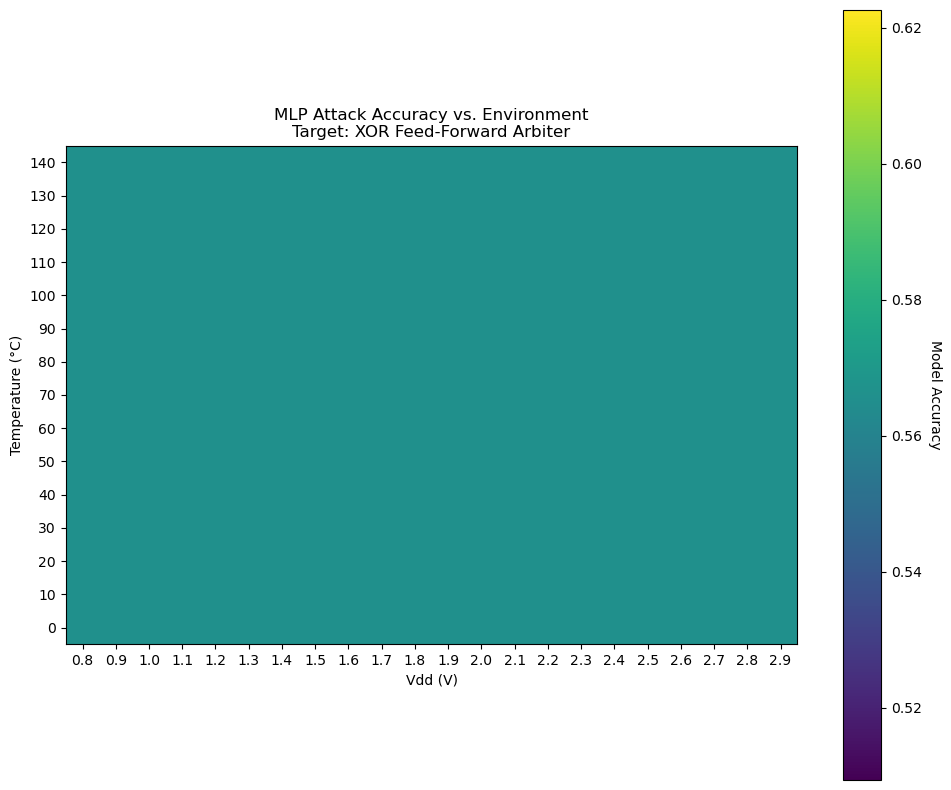

Saved full grid accuracy to XOR Feed-Forward Arbiter_master_accuracy.csv
Saved summary stats to ALL_PUF_attack_summary.csv
Mean: 0.5660, Std: 0.0000


In [10]:
from pypuf.simulation import XORFeedForwardArbiterPUF

# XOR Feed-Forward Arbiter PUF: combines XOR composition with feed-forward connections
# k=4 for XOR strength, ff=[(10, 20), (30, 40)] for feed-forward indices
p_nom = XORFeedForwardArbiterPUF(n=n_bits, k=4, ff=[(10, 20), (30, 40)], seed=puf_seed, noisiness=0.05, temperature=nom_temp, vdd=nom_vdd)
train_crps = ChallengeResponseSet.from_simulation(p_nom, N=100000, seed=puf_seed)  # Increased data for XOR+FF

model = MLPAttack2021(train_crps, 42, [n_bits, n_bits], 50, 1e-3,256, 0.01).fit()
model.temperature, model.vdd = nom_temp, nom_vdd

acc_grid = np.zeros((len(temp_range), len(vdd_range)))
for i, t in enumerate(temp_range):
    for j, v in enumerate(vdd_range):
        p_eval = XORFeedForwardArbiterPUF(n=n_bits, k=4, ff=[(10, 20), (30, 40)], seed=puf_seed, temperature=t, vdd=v)
        acc_grid[i, j] = similarity(p_eval, model, seed=42, N=n_test)[0]

plot_environmental_heatmap(acc_grid, temp_range, vdd_range, "XOR Feed-Forward Arbiter", "MLP Attack")